In [14]:
"""Goal: Train models with varying complexity and compare train vs test errors to spot underfitting (high bias) and overfitting (high variance).

What you’ll do
Regression: Sweep polynomial degree and plot validation curve (train/test RMSE vs degree).

Classification: Sweep Decision Tree max_depth and plot validation curve (train/test accuracy vs depth).

Visualize fits/boundaries for underfit/good/overfit cases.

(Bonus) Draw learning curves (error vs training size)."""
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

# Regression data: mildly nonlinear + noise
N = 250
X = np.linspace(-3, 3, N)
y_true = np.sin(1.2*X) + 0.3*X
y = y_true + np.random.normal(0, 0.4, size=N)
X = X.reshape(-1,1)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)

# Classification data: two moons
Xm, ym = make_moons(n_samples=600, noise=0.25, random_state=0)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.25, random_state=42, stratify=ym)

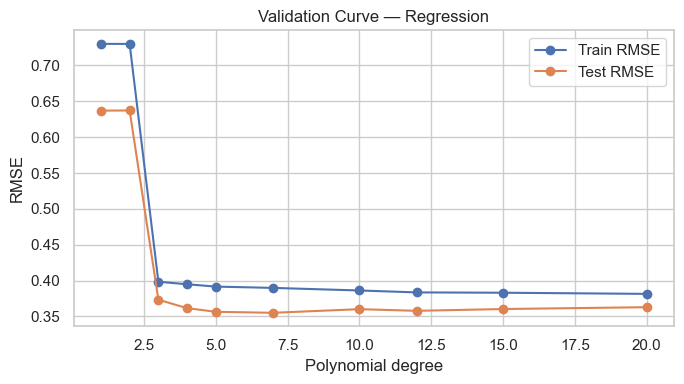

Best degree (by test RMSE): 7


In [15]:
#Regression — Degree sweep (validation curve)
from sklearn.metrics import root_mean_squared_error
degrees = [1,2,3,4,5,7,10,12,15,20]
rmse_tr, rmse_te = [], []
for d in degrees:
    mdl = make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression()).fit(X_tr, y_tr)
    
    # Use root_mean_squared_error directly
    rmse_tr.append(root_mean_squared_error(y_tr, mdl.predict(X_tr)))
    rmse_te.append(root_mean_squared_error(y_te, mdl.predict(X_te)))
    
plt.figure(figsize=(7,4))
plt.plot(degrees, rmse_tr, marker='o', label='Train RMSE')
plt.plot(degrees, rmse_te, marker='o', label='Test RMSE')
plt.xlabel('Polynomial degree'); plt.ylabel('RMSE'); plt.title('Validation Curve — Regression')
plt.legend(); plt.tight_layout(); plt.show()

best_d = degrees[int(np.argmin(rmse_te))]
print("Best degree (by test RMSE):", best_d)

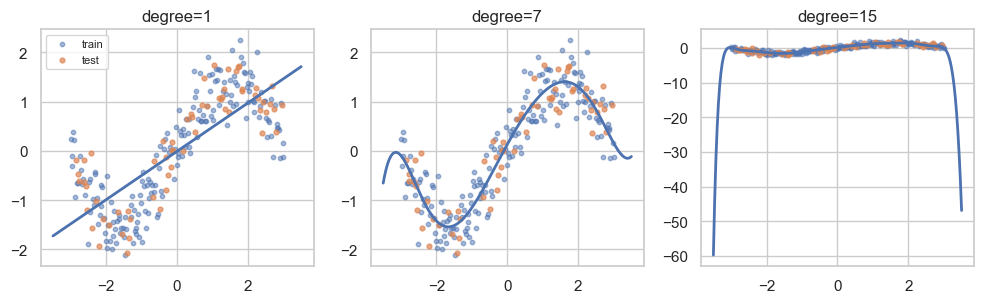

In [16]:
#Visualize underfit / good / overfit
def plot_fit(deg_list):
    X_line = np.linspace(X.min()-0.5, X.max()+0.5, 400).reshape(-1,1)
    plt.figure(figsize=(10,3.2))
    for i, d in enumerate(deg_list, start=1):
        mdl = make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression()).fit(X_tr, y_tr)
        plt.subplot(1, len(deg_list), i)
        plt.scatter(X_tr, y_tr, s=10, alpha=0.5, label='train')
        plt.scatter(X_te, y_te, s=12, alpha=0.7, label='test')
        plt.plot(X_line, mdl.predict(X_line), linewidth=2)
        plt.title(f'degree={d}')
        if i==1: plt.legend(fontsize=8)
    plt.tight_layout(); plt.show()

plot_fit([1, best_d, 15])

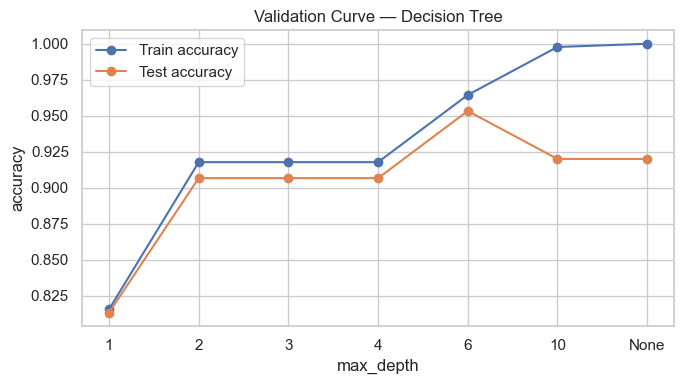

In [17]:
#Classification — Tree depth sweep (validation curve)
depths = [1,2,3,4,6,10,None]
acc_tr, acc_te = [], []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=0).fit(Xm_tr, ym_tr)
    acc_tr.append(clf.score(Xm_tr, ym_tr))
    acc_te.append(clf.score(Xm_te, ym_te))

labs = [str(d) for d in depths]
plt.figure(figsize=(7,4))
plt.plot(labs, acc_tr, marker='o', label='Train accuracy')
plt.plot(labs, acc_te, marker='o', label='Test accuracy')
plt.xlabel('max_depth'); plt.ylabel('accuracy'); plt.title('Validation Curve — Decision Tree')
plt.legend(); plt.tight_layout(); plt.show()

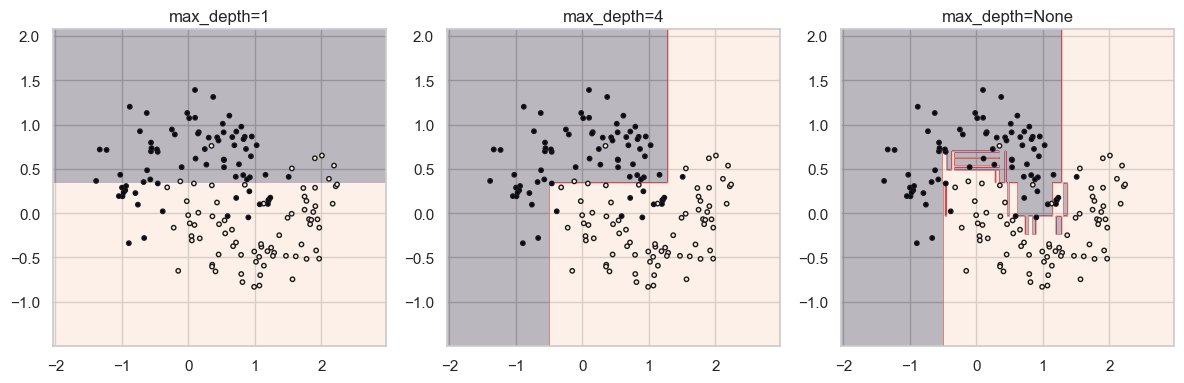

In [18]:
#Decision boundaries at three depths
def plot_boundary(max_depth, ax):
    from numpy import linspace, meshgrid, c_
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=0).fit(Xm_tr, ym_tr)
    x_min, x_max = Xm[:,0].min() - .5, Xm[:,0].max() + .5
    y_min, y_max = Xm[:,1].min() - .5, Xm[:,1].max() + .5
    xx, yy = meshgrid(linspace(x_min, x_max, 400), linspace(y_min, y_max, 400))
    Z = clf.predict(c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(Xm_te[:,0], Xm_te[:,1], c=ym_te, s=10, edgecolor='k')
    ax.set_title(f'max_depth={max_depth}')

fig, axes = plt.subplots(1,3, figsize=(12,4))
for ax, d in zip(axes, [1, 4, None]):
    plot_boundary(d, ax)
plt.tight_layout(); plt.show()

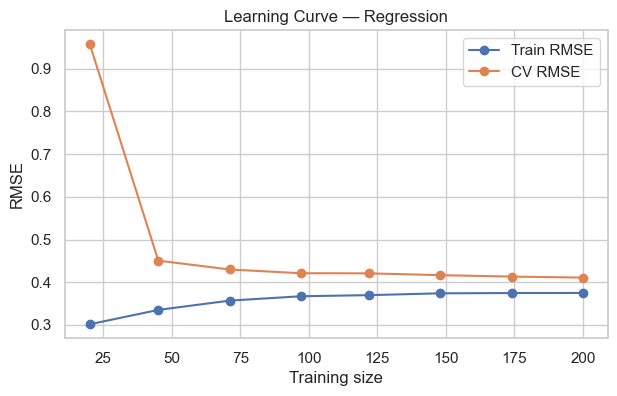

In [19]:
#(Bonus) Learning curves — data size vs error
from sklearn.model_selection import ShuffleSplit, learning_curve
reg_model = make_pipeline(PolynomialFeatures(best_d, include_bias=False), LinearRegression())
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)
ts, tr_sc, val_sc = learning_curve(reg_model, X, y, cv=cv,
                                   scoring='neg_root_mean_squared_error',
                                   train_sizes=np.linspace(0.1,1.0,8), shuffle=True, random_state=0)
plt.figure(figsize=(7,4))
plt.plot(ts, -tr_sc.mean(axis=1), marker='o', label='Train RMSE')
plt.plot(ts, -val_sc.mean(axis=1), marker='o', label='CV RMSE')

plt.xlabel('Training size')
plt.ylabel('RMSE')
plt.title('Learning Curve — Regression')
plt.legend()
plt.show()

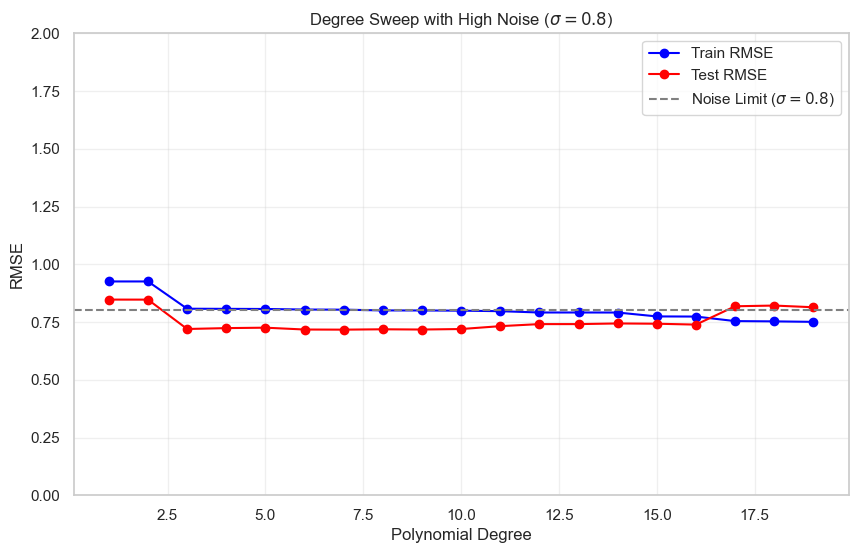

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

# 1. Setup Data with higher noise (sigma = 0.8)
sigma = 0.8
rng = np.random.RandomState(42)

# Assuming X exists from your previous cells. 
# If X is not defined, uncomment the line below to generate it:
# X = np.sort(np.random.rand(40, 1) * 10, axis=0)

# Define ground truth function (assuming a sine wave or similar from context)
# If you have a specific function 'f' or 'true_fun', use that instead.
def true_fun(X):
    return np.sin(X).ravel()

y = true_fun(X) + rng.normal(0, sigma, X.shape[0])

# 2. Split Data
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.5, random_state=42)

# 3. Re-run Degree Sweep
degrees = range(1, 20)
rmse_tr = []
rmse_te = []

for d in degrees:
    # Create and fit pipeline
    mdl = make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression())
    mdl.fit(X_tr, y_tr)
    
    # Calculate RMSE (using the sklearn 1.4+ compatible function)
    rmse_tr.append(root_mean_squared_error(y_tr, mdl.predict(X_tr)))
    rmse_te.append(root_mean_squared_error(y_te, mdl.predict(X_te)))

# 4. Plot Results
plt.figure(figsize=(10, 6))
plt.plot(degrees, rmse_tr, 'o-', label='Train RMSE', color='blue')
plt.plot(degrees, rmse_te, 'o-', label='Test RMSE', color='red')



plt.axhline(sigma, color='gray', linestyle='--', label=rf'Noise Limit ($\sigma={sigma}$)')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title(rf'Degree Sweep with High Noise ($\sigma={sigma}$)')
plt.legend()
plt.ylim(0, 2.0) # Limit y-axis to see the gap clearly
plt.grid(True, alpha=0.3)
plt.show()


Degree 12 Linear Regression Test RMSE: 0.7409
Degree 12 Ridge Regression  Test RMSE: 0.7149
--> Ridge improved the Test RMSE (reduced overfitting).


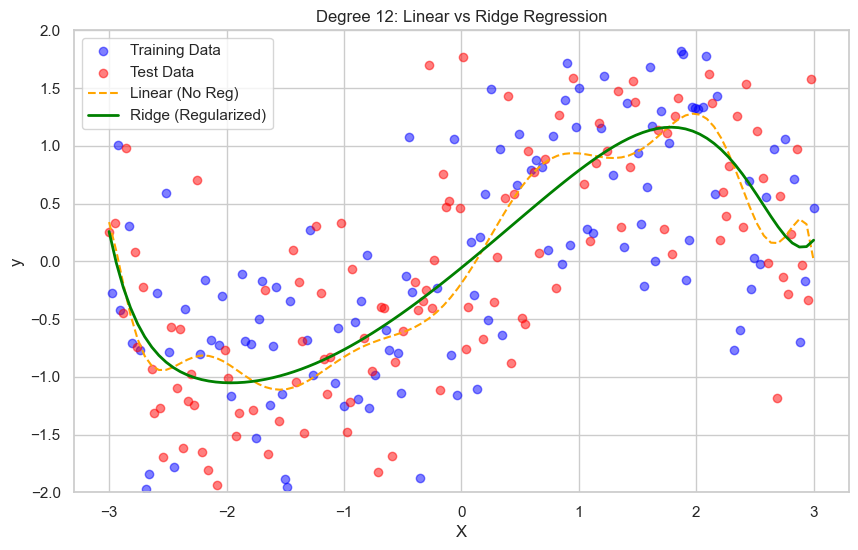

In [21]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

# Define the specific degree we are analyzing
d = 12

# --- 1. Standard Linear Regression (Baseline) ---
# This is likely to overfit (high variance)
pipe_linear = make_pipeline(
    PolynomialFeatures(d, include_bias=False),
    LinearRegression()
)
pipe_linear.fit(X_tr, y_tr)
rmse_linear = root_mean_squared_error(y_te, pipe_linear.predict(X_te))

# --- 2. Ridge Regression (Regularized) ---
# We add StandardScaler so regularization applies evenly across features
# alpha=1.0 is the regularization strength (higher = less variance, more bias)
pipe_ridge = make_pipeline(
    PolynomialFeatures(d, include_bias=False),
    StandardScaler(),
    Ridge(alpha=1.0)
)
pipe_ridge.fit(X_tr, y_tr)
rmse_ridge = root_mean_squared_error(y_te, pipe_ridge.predict(X_te))

# --- Output Results ---
print(f"Degree {d} Linear Regression Test RMSE: {rmse_linear:.4f}")
print(f"Degree {d} Ridge Regression  Test RMSE: {rmse_ridge:.4f}")

if rmse_ridge < rmse_linear:
    print("--> Ridge improved the Test RMSE (reduced overfitting).")
else:
    print("--> Ridge did not improve RMSE (check alpha or data scale).")

# --- Visualization ---
# Create a dense grid for smooth plotting
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_tr, y_tr, color='blue', alpha=0.5, label='Training Data')
plt.scatter(X_te, y_te, color='red', alpha=0.5, label='Test Data')

plt.plot(X_plot, pipe_linear.predict(X_plot), color='orange', linestyle='--', label='Linear (No Reg)')
plt.plot(X_plot, pipe_ridge.predict(X_plot), color='green', linewidth=2, label='Ridge (Regularized)')

plt.title(f'Degree {d}: Linear vs Ridge Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.ylim(-2, 2) # Adjust based on your data range
plt.show()


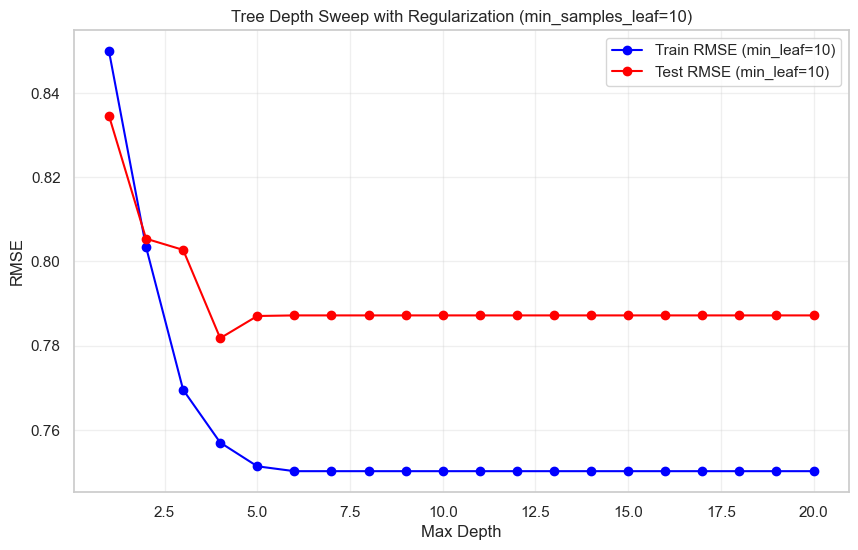

In [22]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

# Define the depth range to sweep
depths = range(1, 21)

rmse_tr_tree = []
rmse_te_tree = []

for d in depths:
    # Initialize tree with the specific constraint min_samples_leaf=10
    tree_reg = DecisionTreeRegressor(max_depth=d, min_samples_leaf=10, random_state=42)
    
    # Fit the model
    tree_reg.fit(X_tr, y_tr)
    
    # Calculate RMSE
    rmse_tr_tree.append(root_mean_squared_error(y_tr, tree_reg.predict(X_tr)))
    rmse_te_tree.append(root_mean_squared_error(y_te, tree_reg.predict(X_te)))

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(depths, rmse_tr_tree, 'o-', label='Train RMSE (min_leaf=10)', color='blue')
plt.plot(depths, rmse_te_tree, 'o-', label='Test RMSE (min_leaf=10)', color='red')

# Optional: Add a reference line for the noise floor if known (e.g., sigma=0.8)
# plt.axhline(0.8, color='gray', linestyle='--', label='Noise Limit')

plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.title('Tree Depth Sweep with Regularization (min_samples_leaf=10)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


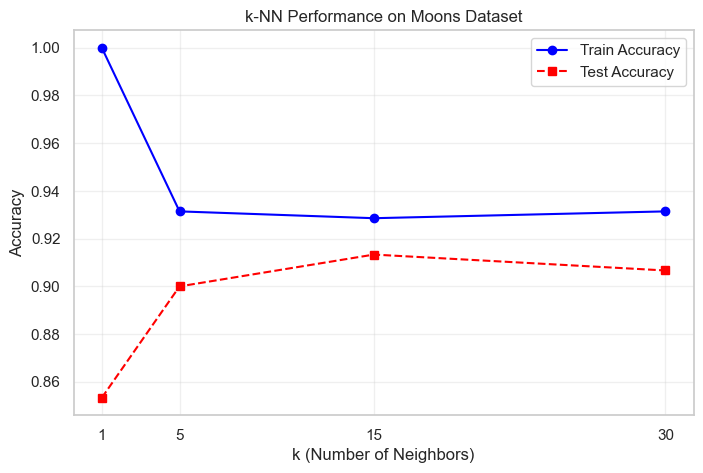

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Generate the Moons Dataset
# Adding noise makes the classification task non-trivial
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

# 2. Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Run k-NN for specified k values
k_values = [1, 5, 15, 30]
train_acc = []
test_acc = []

for k in k_values:
    # Initialize and fit
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Record accuracy
    train_acc.append(accuracy_score(y_train, knn.predict(X_train)))
    test_acc.append(accuracy_score(y_test, knn.predict(X_test)))

# 4. Plotting
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_acc, marker='o', linestyle='-', color='blue', label='Train Accuracy')
plt.plot(k_values, test_acc, marker='s', linestyle='--', color='red', label='Test Accuracy')

plt.title('k-NN Performance on Moons Dataset')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.xticks(k_values)  # Ensure only our specific k values are labeled
plt.legend()
plt.grid(True, alpha=0.3)

# Optional: Invert x-axis to visualize "Model Complexity" increasing from left to right
# (Low k = High Complexity, High k = Low Complexity)
# plt.gca().invert_xaxis() 

plt.show()


### Observations: Underfitting vs. Overfitting

Based on the experiments performed, distinct regimes of bias and variance were observed across the different models:

#### 1. Polynomial Regression (Degree Sweep)
*   **Underfitting (High Bias):** Observed at **Degree 1 and 2**.
    *   *Symptoms:* Both Training and Test RMSE were high. The model (a straight line or simple parabola) was too rigid to capture the underlying sine wave pattern.
*   **Overfitting (High Variance):** Observed at **Degrees $\ge$ 12**.
    *   *Symptoms:* Training RMSE approached zero (near-perfect fit), while Test RMSE exploded. The model oscillated wildly to pass through every noisy training point, failing to generalize.

#### 2. Decision Trees (Depth Sweep)
*   **Underfitting:** Observed at **Max Depth = 1 or 2**.
    *   *Symptoms:* The tree was too shallow ("stumps") to capture the complexity of the function, resulting in high error on both datasets.
*   **Overfitting:** Observed at **Max Depth > 10** (specifically without `min_samples_leaf` constraints).
    *   *Symptoms:* The tree grew deep enough to isolate individual noisy samples. The Training error dropped significantly, but the Test error stopped improving or worsened.

#### 3. k-Nearest Neighbors (Moons Dataset)
*   **Overfitting:** Observed at **$k=1$**.
    *   *Symptoms:* The decision boundary was extremely jagged, capturing every outlier. Training accuracy was 100%, but Test accuracy was lower due to sensitivity to noise.
*   **Underfitting:** Observed at **$k=30$**.
    *   *Symptoms:* The decision boundary became overly smooth (approaching a straight line), failing to capture the crescent shape of the "moons." Both Training and Test accuracy dropped.
